## Telco Customer Data Predicting Monlthy Charges using Linear Regression

In [43]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, mean_absolute_percentage_error)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

In [44]:
df= pd.read_csv("data/telco-churn.csv")
df.shape

(7043, 21)

In [45]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [46]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [47]:
df.sample(10)
# getting random values

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3880,9470-RTWDV,Male,0,Yes,Yes,26,Yes,Yes,DSL,No,...,Yes,Yes,Yes,Yes,One year,Yes,Credit card (automatic),82.00,2083.1,No
6278,7208-PSIHR,Female,0,Yes,No,70,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),104.30,7188.5,No
6332,4378-MYPGO,Male,0,Yes,Yes,68,Yes,No,Fiber optic,Yes,...,Yes,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.25,7173.15,No
1277,4821-WQOYN,Female,0,Yes,Yes,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),20.10,1326.25,No
6901,2925-MXLSX,Female,0,No,No,30,Yes,Yes,DSL,No,...,Yes,No,Yes,No,One year,Yes,Credit card (automatic),68.95,2038.7,No
504,5736-YEJAX,Male,0,No,Yes,69,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Credit card (automatic),79.45,5502.55,No
2069,6356-ELRKD,Female,0,No,No,1,Yes,No,Fiber optic,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.60,95.6,Yes
3668,1353-GHZOS,Male,0,Yes,No,22,Yes,No,DSL,Yes,...,No,No,Yes,No,One year,Yes,Bank transfer (automatic),59.75,1374.35,No
6705,3733-ZEECP,Male,0,Yes,Yes,22,Yes,No,DSL,No,...,No,Yes,No,No,Month-to-month,Yes,Electronic check,51.10,1232.9,No
1775,2307-FYNNL,Male,1,No,No,65,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,109.05,7108.2,No


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [49]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning 
Total Charges contains some blank strings so lets turn them to NaN, and then those rows can be filled with MonlthyCharges* tenure , and confirm if there are any missing values or duplicates rows left

In [50]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Blank / invalid TotalCharges rows:", df["TotalCharges"].isna().sum())

df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"] * df["tenure"])

print("Total missing values after cleaning:", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

Blank / invalid TotalCharges rows: 11
Total missing values after cleaning: 0
Duplicate rows: 0


## Exploratory data analysis(EDA)

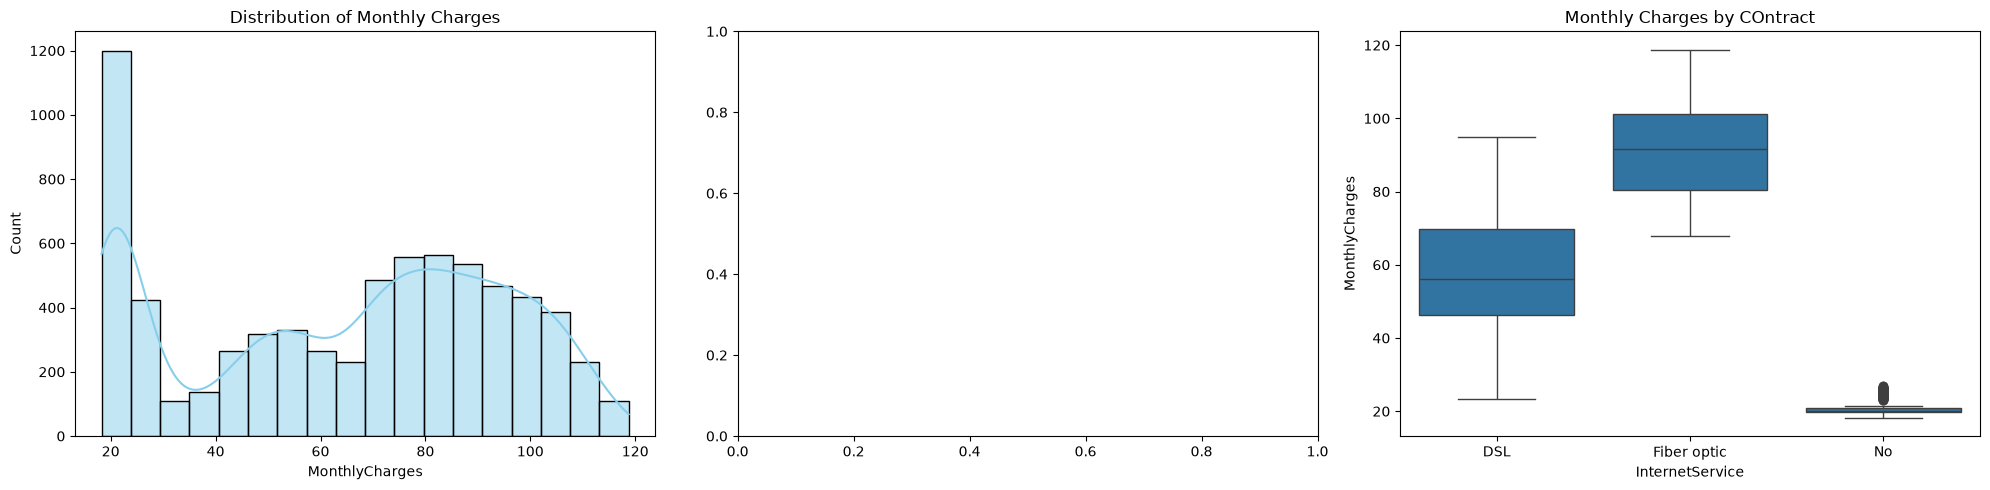

In [51]:
fig,axes = plt.subplots(1,3, figsize=(20,5))
sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Distribution of Monthly Charges")
sns.boxplot(data=df, x='InternetService', y="MonthlyCharges", ax= axes[2])
axes[2].set_title("Monthly Charges by COntract")
plt.tight_layout()
plt.show()

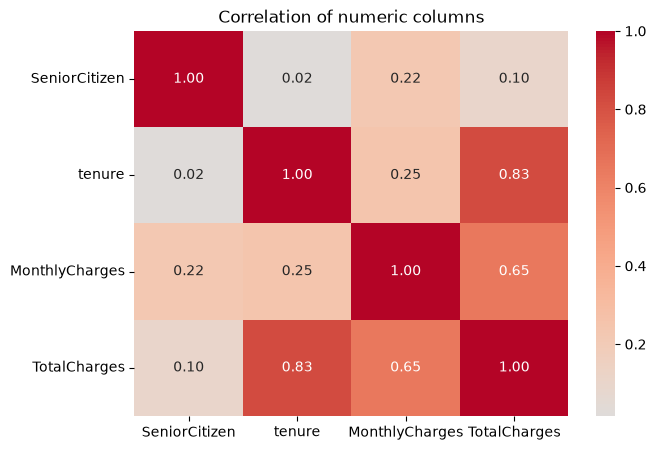

corr(Total Charges, tenure x Monthly Charges)=


In [52]:
numeric_raw= df.select_dtypes(include="number")
plt.figure(figsize=(7,5))
sns.heatmap(numeric_raw.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Correlation of numeric columns")
plt.show()

leak_corr= np.corrcoef(df["TotalCharges"], df['tenure']* df["MonthlyCharges"])[0,1]
print("corr(Total Charges, tenure x Monthly Charges)=")
leak_corr:.4

Monthly charges is not normally distributed, and there is cluster of cheap phone only customers and a wide spread of internet customers.
The type of internet service shifts the prove level a lot (Fibre optic might be expensive and NO internet is cheap)
Total Charges is almost exactly tenure * Monthly Charges using it to predict Monthly Charges would be data leakage

## 5. Feature engineering

Every transformation below is **row-wise** (it only looks at one customer at a time), so it is safe to apply to the full table before the train/test split – no information leaks from test to train.

| Step | What we do | Why |
|---|---|---|
| Harmonise labels | `"No internet service"` and `"No phone service"` → `"No"` | These are duplicates of `InternetService == "No"` / `PhoneService == "No"` and only create redundant dummy columns |
| `num_addons` | Count of the 6 add-ons (security, backup, protection, support, TV, movies) | Each add-on adds to the bill – the count summarises this |
| `num_streaming`, `num_protection` | Counts inside the two add-on families | Streaming and protection are priced differently |
| `has_internet`, `is_fiber`, `has_phone`, `multiple_lines_flag` | Binary flags | Direct price drivers |
| `total_services` | add-ons + internet + phone + multiple lines | Overall "size" of the plan |
| `auto_pay`, `is_month_to_month`, `has_family` | Business-style flags | Capture contract / payment behaviour |
| `log_tenure`, `tenure_sq`, `tenure_group` | Non-linear versions of tenure | Customers' plans change non-linearly over their lifetime |

**Data leakage `TotalCharges`.** `TotalCharges ≈ tenure × MonthlyCharges`, so we are removing total charges too 

`customerID` is just an identifier and is dropped.

In [53]:
def engineer_features(data):
    d = data.copy()
    d = d.drop(columns=["customerID"], errors="ignore")

    #Harmonise duplicate labels
    addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection","TechSupport", "StreamingTV", "StreamingMovies"]
    d[addon_cols] = d[addon_cols].replace("No internet service", "No")
    d["MultipleLines"] = d["MultipleLines"].replace("No phone service", "No")

    # Counts
    d["num_addons"] = (d[addon_cols] == "Yes").sum(axis=1)
    d["num_streaming"] = (d[["StreamingTV", "StreamingMovies"]] == "Yes").sum(axis=1)
    d["num_protection"] = (d[["OnlineSecurity", "OnlineBackup",
                              "DeviceProtection", "TechSupport"]] == "Yes").sum(axis=1)

    # Binary flags
    d["has_internet"] = (d["InternetService"] != "No").astype(int)
    d["is_fiber"] = (d["InternetService"] == "Fiber optic").astype(int)
    d["has_phone"] = (d["PhoneService"] == "Yes").astype(int)
    d["multiple_lines_flag"] = (d["MultipleLines"] == "Yes").astype(int)
    d["total_services"] = (d["num_addons"] + d["has_internet"] + d["has_phone"] + d["multiple_lines_flag"])
    d["auto_pay"] = d["PaymentMethod"].str.contains("automatic", case=False).astype(int)
    d["is_month_to_month"] = (d["Contract"] == "Month-to-month").astype(int)
    d["has_family"] = ((d["Partner"] == "Yes") | (d["Dependents"] == "Yes")).astype(int)

    # Tenure transformations
    d["log_tenure"] = np.log1p(d["tenure"])
    d["tenure_sq"] = d["tenure"] ** 2
    d["tenure_group"] = pd.cut(d["tenure"], bins=[-1, 12, 24, 48, 60, np.inf],
    labels=["0-12", "13-24", "25-48", "49-60", "61+"]).astype(str)

    #Leakage control
    if not False:
        d = d.drop(columns=["TotalCharges"], errors="ignore")
    return d


X_all = engineer_features(df.drop(columns=['MonthlyCharges']))
y = df['MonthlyCharges']
print("Feature matrix shape:", X_all.shape)
X_all.head()

Feature matrix shape: (7043, 32)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,is_fiber,has_phone,multiple_lines_flag,total_services,auto_pay,is_month_to_month,has_family,log_tenure,tenure_sq,tenure_group
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,...,0,0,0,2,0,1,1,0.693147,1,0-12
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,0,1,0,4,0,0,0,3.555348,1156,25-48
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,0,1,0,4,0,1,0,1.098612,4,0-12
3,Male,0,No,No,45,No,No,DSL,Yes,No,...,0,0,0,4,1,0,0,3.828641,2025,25-48
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,1,1,0,2,0,1,0,1.098612,4,0-12


In [54]:
new_feats = ["num_addons", "num_streaming", "num_protection", "total_services","has_internet", "is_fiber", "has_phone", "multiple_lines_flag",
             "auto_pay", "is_month_to_month", "has_family", "log_tenure", "tenure_sq"]
corr_with_target = (pd.concat([X_all[new_feats], y], axis=1).corr()['MonthlyCharges'].drop('MonthlyCharges').sort_values(ascending=False))
corr_with_target.to_frame("corr with MonthlyCharges")

,corr with MonthlyCharges
total_services,0.851380
is_fiber,0.787066
has_internet,0.763557
num_addons,0.724706
num_streaming,0.717871
num_protection,0.564924
multiple_lines_flag,0.490434
has_phone,0.247398
log_tenure,0.239706
tenure_sq,0.238198


## Train / test split and preprocessing

* **70 % train / 30 % test** (same split as your original notebook, `random_state=42`).
* The preprocessing is wrapped in a `ColumnTransformer` inside a `Pipeline`, so scaling and encoding are learned **only from the training data** (and re-learned inside every cross-validation fold). This prevents leakage.
  * numeric columns → median imputation (safety net) + `StandardScaler`
  * categorical columns → most-frequent imputation (safety net) + `OneHotEncoder` (binary columns become a single 0/1 column)

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.3, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)
print(f"Target mean  train={y_train.mean():.2f}  test={y_test.mean():.2f}")

numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()
print("\nNumeric features :", len(numeric_features), numeric_features)
print("Categorical features:", len(categorical_features), categorical_features)


def make_preprocessor(scale=True):
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scaler", StandardScaler()))
    numeric_pipe = Pipeline(num_steps)
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ])


def clean_names(names):
    return [n.split("__", 1)[1] for n in names]

Train: (4930, 32)  Test: (2113, 32)
Target mean  train=64.80  test=64.68

Numeric features : 15 ['SeniorCitizen', 'tenure', 'num_addons', 'num_streaming', 'num_protection', 'has_internet', 'is_fiber', 'has_phone', 'multiple_lines_flag', 'total_services', 'auto_pay', 'is_month_to_month', 'has_family', 'log_tenure', 'tenure_sq']
Categorical features: 17 ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn', 'tenure_group']


## Evaluation Helper

In [56]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [64]:
def evaluate(y_true, y_pred, n_features, label):
    n = len(y_true)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    mse = mean_squared_error(y_true, y_pred)
    return {"Dataset": label,
            "MAE": mean_absolute_error(y_true, y_pred),
            "MSE": mse,
            "RMSE": np.sqrt(mse),
            "R2": r2,
            "Adj_R2": adj_r2,
            "MAPE_%": mean_absolute_percentage_error(y_true, y_pred) * 100}


def error_table(model, name, n_features):
    rows = []
    for label, X_, y_ in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
        row = evaluate(y_, model.predict(X_), n_features, label)
        row["Model"] = name
        rows.append(row)
    return pd.DataFrame(rows)[["Model", "Dataset", "MAE", "MSE", "RMSE", "R2", "Adj_R2", "MAPE_%"]]


def cv_report(model, name, X=None, y_=None):
    X = X_train if X is None else X
    y_ = y_train if y_ is None else y_
    s = cross_validate(model, X, y_, cv=cv, n_jobs=-1, return_train_score=True,
    scoring={"mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error","r2": "r2"})
    out = pd.DataFrame({
        "Metric": ["MAE", "RMSE", "R2"],
        "CV train (mean)": [-s["train_mae"].mean(), -s["train_rmse"].mean(), s["train_r2"].mean()],
        "CV validation (mean)": [-s["test_mae"].mean(), -s["test_rmse"].mean(), s["test_r2"].mean()],
        "CV validation (std)": [s["test_mae"].std(), s["test_rmse"].std(), s["test_r2"].std()],
    })
    print(f"5-fold cross-validation on the training set - {name}")
    return out


def diagnostic_plots(y_true, y_pred, title):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    resid = y_true - y_pred
    fig, ax = plt.subplots(2, 2, figsize=(14, 10))

    ax[0, 0].scatter(y_true, y_pred, alpha=0.4, s=14)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax[0, 0].plot(lims, lims, "r--")
    ax[0, 0].set(xlabel="Actual MonthlyCharges", ylabel="Predicted", title="Actual vs predicted")

    ax[0, 1].scatter(y_pred, resid, alpha=0.4, s=14)
    ax[0, 1].axhline(0, color="r", ls="--")
    ax[0, 1].set(xlabel="Predicted", ylabel="Residual (actual - predicted)", title="Residuals vs predicted")

    sns.histplot(resid, kde=True, ax=ax[1, 0], color="seagreen")
    ax[1, 0].set(xlabel="Residual", title="Residual distribution")

    stats.probplot(resid, dist="norm", plot=ax[1, 1])
    ax[1, 1].set_title("Q-Q plot of residuals")

    fig.suptitle(title, fontsize=15, y=1.01)
    plt.tight_layout()
    plt.show()


def worst_predictions(model, X_, y_, n=10):
    out = X_.copy()
    out["actual"] = y_.values
    out["predicted"] = model.predict(X_)
    out["abs_error"] = (out["actual"] - out["predicted"]).abs()
    cols = ["actual", "predicted", "abs_error", "InternetService", "Contract", "num_addons", "tenure"]
    return out.nlargest(n, "abs_error")[cols]


def coef_plot(names, coefs, title, top=15):
    s = pd.Series(coefs, index=names)
    top_s = s.reindex(s.abs().sort_values(ascending=False).head(top).index).sort_values()
    plt.figure(figsize=(9, 6))
    colors = ["tomato" if v < 0 else "steelblue" for v in top_s.values]
    plt.barh(top_s.index, top_s.values, color=colors)
    plt.axvline(0, color="k", lw=0.8)
    plt.title(title)
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()
    

In [65]:
X_raw = df.drop(columns=["customerID", 'MonthlyCharges'])
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_raw, df['MonthlyCharges'], test_size=0.3, random_state=42)

try:
    LinearRegression().fit(Xr_train, yr_train)
except Exception as e:
    print(f"{type(e).__name__}: {e}")
    print("\nText columns that caused it:", Xr_train.select_dtypes(exclude="number").columns.tolist())

ValueError: could not convert string to float: 'Male'

Text columns that caused it: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


## Baseline and Linear regression

In [66]:
baseline = Pipeline([("prep", make_preprocessor()),
                     ("model", DummyRegressor(strategy="mean"))]).fit(X_train, y_train)

lin_reg = Pipeline([("prep", make_preprocessor()),
                    ("model", LinearRegression())]).fit(X_train, y_train)

n_feat = lin_reg.named_steps["prep"].get_feature_names_out().shape[0]
print("Number of model input features after encoding:", n_feat)
print("Intercept:", round(float(lin_reg.named_steps["model"].intercept_), 4))

Number of model input features after encoding: 43
Intercept: 60.5744


## Errors 

In [67]:
results = pd.concat([error_table(baseline, "Baseline (mean)", 0),
error_table(lin_reg, "Linear Regression", n_feat)], ignore_index=True)
results

,Model,Dataset,MAE,MSE,RMSE,R2,Adj_R2,MAPE_%
0,Baseline (mean),Train,26.301193,908.310481,30.138190,0.000000,0.000000,68.910978
1,Baseline (mean),Test,26.024864,898.221013,29.970336,-0.000014,-0.000014,68.525567
2,Linear Regression,Train,0.774751,1.023155,1.011511,0.998874,0.998864,1.394079
3,Linear Regression,Test,0.795600,1.111779,1.054409,0.998762,0.998737,1.387003


In [68]:
cv_report(lin_reg, "Linear Regression")

5-fold cross-validation on the training set - Linear Regression


,Metric,CV train (mean),CV validation (mean),CV validation (std)
0,MAE,0.774231,0.779316,0.014697
1,RMSE,1.010868,1.016919,0.022234
2,R2,0.998875,0.998859,0.000061


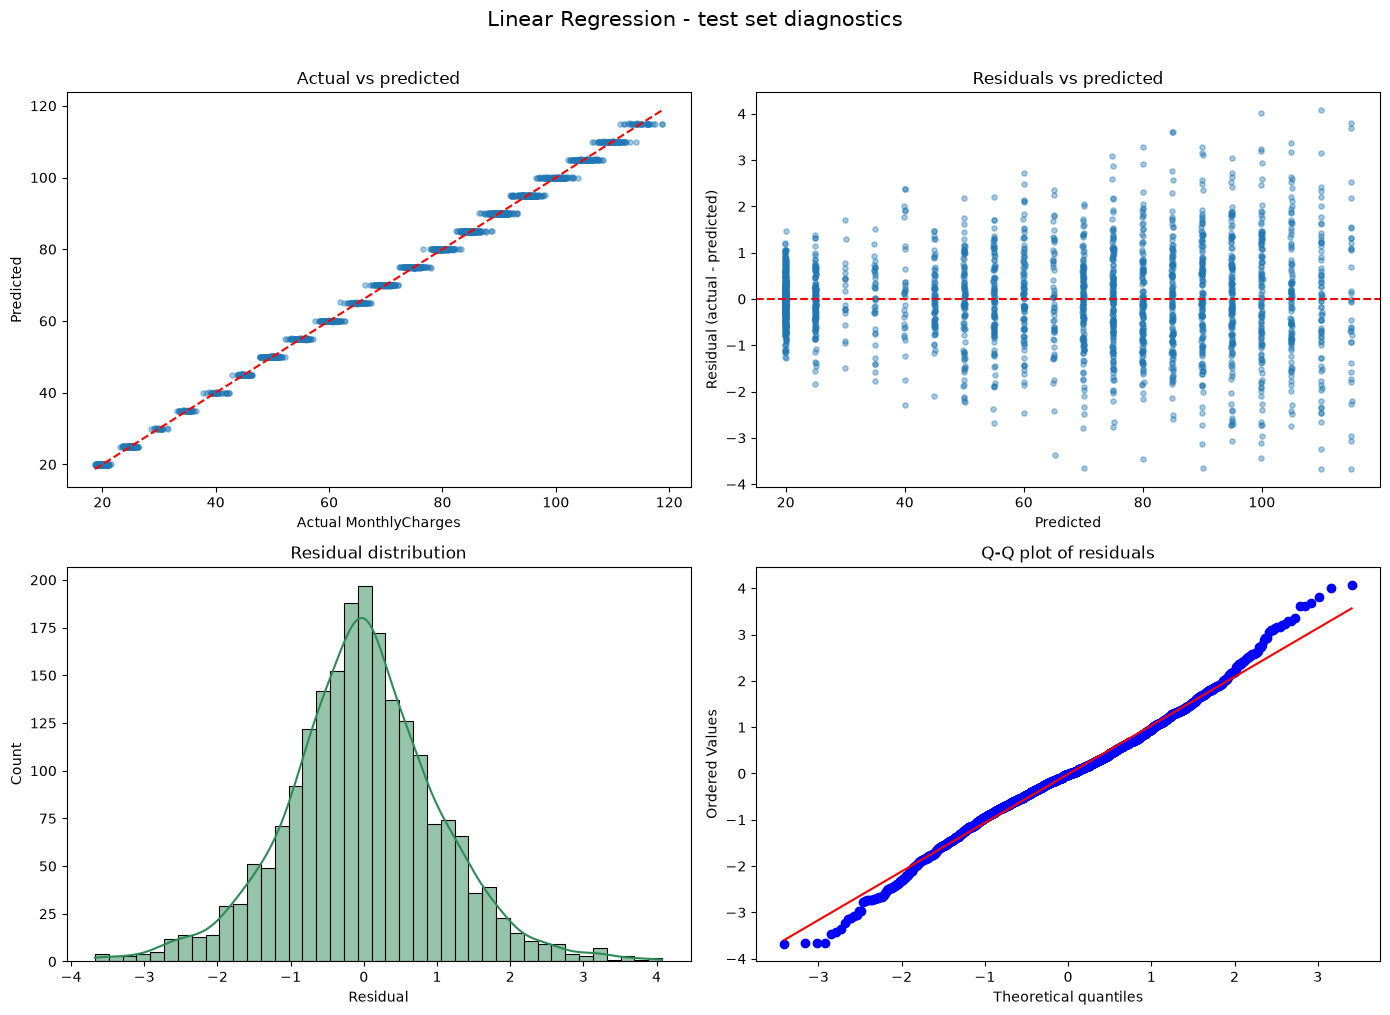

In [69]:
y_pred_test = lin_reg.predict(X_test)
diagnostic_plots(y_test, y_pred_test, "Linear Regression - test set diagnostics")

## Coefficients

,feature,coefficient
0,is_fiber,9.473656
1,has_internet,8.541788
2,has_phone,4.867426
3,InternetService_Fiber optic,4.700189
4,total_services,4.633617
5,num_streaming,4.043009
6,InternetService_No,-3.529468
7,num_addons,2.813948
8,StreamingTV_Yes,1.744540
9,StreamingMovies_Yes,1.709381


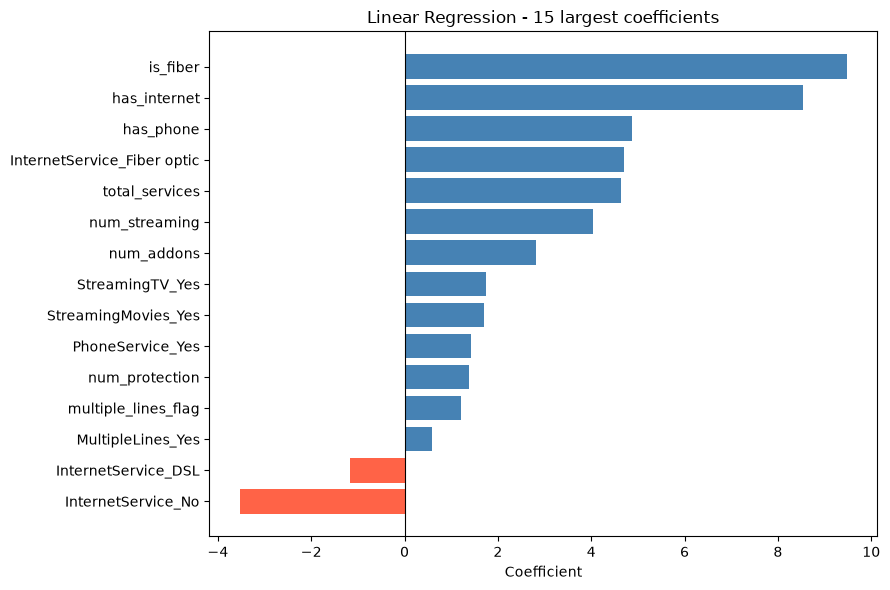

In [70]:
names = clean_names(lin_reg.named_steps["prep"].get_feature_names_out())
coefs = lin_reg.named_steps["model"].coef_

coef_df = (pd.DataFrame({"feature": names, "coefficient": coefs}).sort_values("coefficient", key=np.abs, ascending=False).reset_index(drop=True))
display(coef_df.head(20))
coef_plot(names, coefs, "Linear Regression - 15 largest coefficients")